In [1]:
quarks = """112.72126007080078 -0.2815213203430176 1.4939846992492676
112.72126007080078 -1.4815332889556885 -1.6476080417633057""" # pt, eta, phi

particles = open("sample_event.txt").read().strip() # pt, eta, phi, mass, charge

particles = particles.split("\n")
particles = [particle.split(" ") for particle in particles]
particles = [[float(p[0]), float(p[1]), float(p[2]), float(p[3]), float(p[4])] for p in particles]

quarks = quarks.split("\n")
quarks = [quark.split(" ") for quark in quarks]
quarks = [[float(q[0]), float(q[1]), float(q[2])] for q in quarks]

In [2]:
# Set labels to -1, 0, or 1, depending on how close the particle is to the quark in the eta-phi space (assign all particles in radius 0.8 around the quarks the label of the quark)
import numpy as np

labels = []
for particle in particles:
    for quark_idx, quark in enumerate(quarks):
        if np.sqrt((particle[1] - quark[1])**2 + (particle[2] - quark[2])**2) < 0.8:
            labels.append(quark_idx)
            break
    else:
        labels.append(-1)



/tmp/ipykernel_2094/3721029319.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(particles[:, 1], particles[:, 2], c=colors, cmap='viridis', s=particles[:, 0])
/tmp/ipykernel_2094/3721029319.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


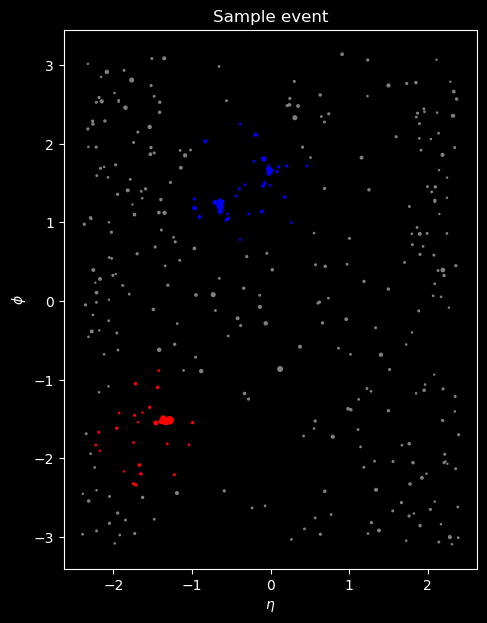

In [3]:
# Now make a matplotlib plot of eta, phi of particles with pt corresponding to size and color tot he label (-1: gray, 0: blue, 1: red)
import matplotlib.pyplot as plt

# Set theme to black
plt.style.use('dark_background')
particles = np.array(particles)
colors = ['gray' if label == -1 else 'blue' if label == 0 else 'red' for label in labels]
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(particles[:, 1], particles[:, 2], c=colors, cmap='viridis', s=particles[:, 0])
ax.set_xlabel(r'$\eta$')
ax.set_ylabel(r'$\phi$')
ax.set_title('Sample event')
# Equal aspect ratio
fig.gca().set_aspect('equal', adjustable='box')
fig.show()


In [4]:
labels

[-1,
 -1,
 -1,
 -1,
 1,
 1,
 -1,
 1,
 -1,
 1,
 1,
 -1,
 1,
 1,
 1,
 -1,
 1,
 -1,
 -1,
 0,
 -1,
 0,
 -1,
 0,
 0,
 0,
 0,
 0,
 -1,
 0,
 0,
 0,
 0,
 0,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 1,
 -1,
 -1,
 -1,
 1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 1,
 -1,
 -1,
 -1,
 1,
 1,
 1,
 1,
 -1,
 1,
 -1,
 -1,
 -1,
 -1,
 -1,
 1,
 0,
 -1,
 0,
 0,
 -1,
 -1,
 0,
 0,
 -1,
 -1,
 0,
 0,
 0,
 -1,
 -1,
 -1,
 0,
 -1,
 -1,
 0,
 -1,
 0,
 0,
 -1,
 0,
 0,
 -1,
 0,
 0,
 0,
 -1,
 0,
 0,
 0,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 0,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -

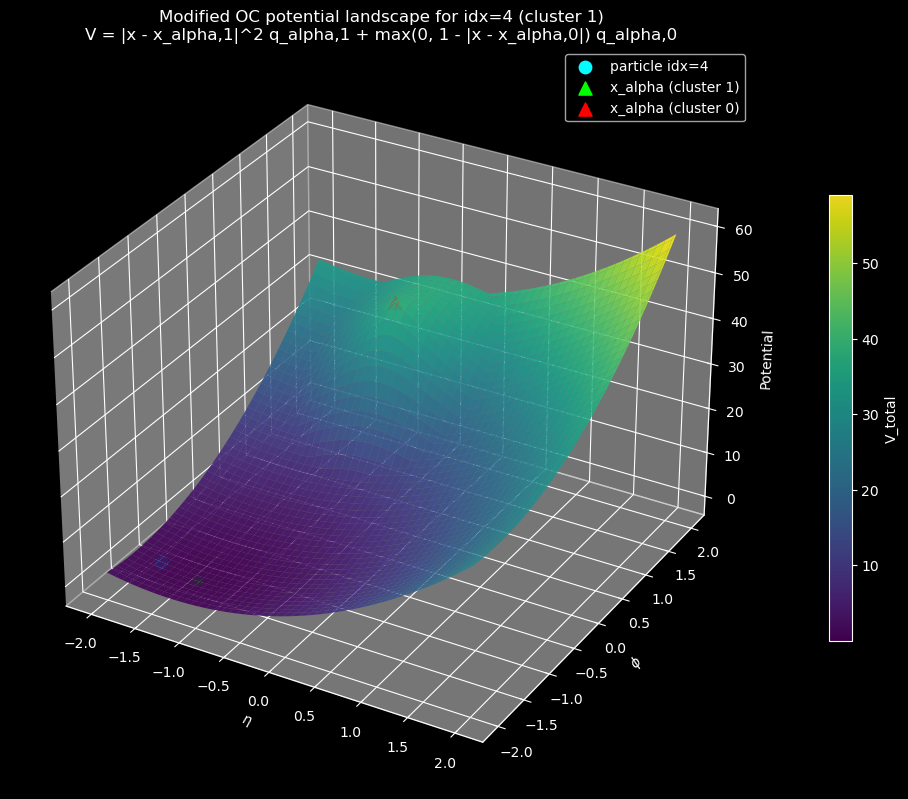

In [17]:
# 3D potential landscape for a selected particle idx
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D projection)

idx = 4  # <- change as needed

particles_np = np.asarray(particles, dtype=float)
labels_np = np.asarray(labels, dtype=int)

if idx < 0 or idx >= len(particles_np):
    raise IndexError(f"idx={idx} is out of range for {len(particles_np)} particles.")

particle_label = int(labels_np[idx])
if particle_label not in (0, 1):
    raise ValueError(
        f"Particle idx={idx} has label={particle_label}. "
        "Choose a particle that belongs to cluster 0 or 1."
    )

# Build x_alpha,k and q_alpha,k from highest-pT particle in each cluster k in {0, 1}
cluster_refs = {}
for k in (0, 1):
    cluster_mask = labels_np == k
    if not np.any(cluster_mask):
        raise ValueError(f"Cluster {k} has no particles in this event.")

    cluster_particles = particles_np[cluster_mask]
    max_pt_local_idx = int(np.argmax(cluster_particles[:, 0]))

    q_alpha_k = float(cluster_particles[max_pt_local_idx, 0])
    x_alpha_k = cluster_particles[max_pt_local_idx, 1:3]  # (eta, phi)

    cluster_refs[k] = {
        "x_alpha": x_alpha_k,
        "q_alpha": q_alpha_k,
    }

own_k = particle_label
other_k = 1 - own_k

x_alpha_own = cluster_refs[own_k]["x_alpha"]
q_alpha_own = cluster_refs[own_k]["q_alpha"]
x_alpha_other = cluster_refs[other_k]["x_alpha"]
q_alpha_other = cluster_refs[other_k]["q_alpha"]

# Potential terms from your modified definition
def v_attractive(x, x_alpha, q_alpha):
    # x is (..., 2) in eta-phi
    return 0.1*np.sum((x - x_alpha) ** 2, axis=-1) * q_alpha


def v_repulsive(x, x_alpha, q_alpha):
    dist = np.linalg.norm(x - x_alpha, axis=-1)
    return np.maximum(0.0, 1.0 - dist) * q_alpha

# Landscape in eta-phi space
eta_min, eta_max = -2, +2
phi_min, phi_max = -2, +2

n_grid = 140
eta_grid = np.linspace(eta_min, eta_max, n_grid)
phi_grid = np.linspace(phi_min, phi_max, n_grid)
ETA, PHI = np.meshgrid(eta_grid, phi_grid)
X = np.stack([ETA, PHI], axis=-1)

V_attr = v_attractive(X, x_alpha_own, q_alpha_own)
V_rep = v_repulsive(X, x_alpha_other, q_alpha_other)
V_total = V_attr + V_rep

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(ETA, PHI, V_total, cmap='viridis', linewidth=0, antialiased=True, alpha=0.92)
fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.08, label='V_total')

# Mark selected particle and the two x_alpha anchors
x_particle = particles_np[idx, 1:3]
v_particle = float(0.1*v_attractive(x_particle, x_alpha_own, q_alpha_own) + v_repulsive(x_particle, x_alpha_other, q_alpha_other))
ax.scatter(x_particle[0], x_particle[1], v_particle, c='cyan', s=80, marker='o', label=f'particle idx={idx}')

v_alpha_own = float(v_attractive(x_alpha_own, x_alpha_own, q_alpha_own) + v_repulsive(x_alpha_own, x_alpha_other, q_alpha_other))
v_alpha_other = float(v_attractive(x_alpha_other, x_alpha_own, q_alpha_own) + v_repulsive(x_alpha_other, x_alpha_other, q_alpha_other))
ax.scatter(x_alpha_own[0], x_alpha_own[1], v_alpha_own, c='lime', s=90, marker='^', label=f'x_alpha (cluster {own_k})')
ax.scatter(x_alpha_other[0], x_alpha_other[1], v_alpha_other, c='red', s=90, marker='^', label=f'x_alpha (cluster {other_k})')

ax.set_xlabel(r'$\eta$')
ax.set_ylabel(r'$\phi$')
ax.set_zlabel('Potential')
ax.set_title(
    f"Modified OC potential landscape for idx={idx} (cluster {own_k})\n"
    f"V = |x - x_alpha,{own_k}|^2 q_alpha,{own_k} + max(0, 1 - |x - x_alpha,{other_k}|) q_alpha,{other_k}"
)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

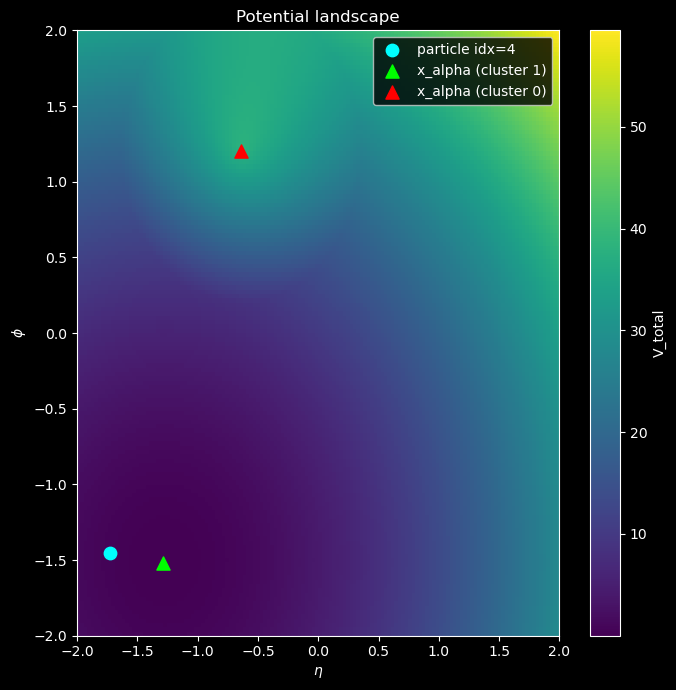

In [ ]:
# 2D potential map in (eta, phi)
fig, ax = plt.subplots(figsize=(7, 7))

# Important: origin='lower' keeps phi increasing upward, matching scatter coordinates
im = ax.imshow(
    V_total,
    cmap='viridis',
    extent=[eta_min, eta_max, phi_min, phi_max],
    origin='lower',
    aspect='auto',
)

ax.set_xlabel(r'$\eta$')
ax.set_ylabel(r'$\phi$')

# Plot all event particles in gray for context
ax.scatter(
    particles_np[:, 1],
    particles_np[:, 2],
    c='gray',
    s=20,
    alpha=0.7,
    marker='o',
    label='event particles',
    zorder=2,
)

# Plot selected particle and both x_alpha anchors in the same coordinate system
ax.scatter(x_particle[0], x_particle[1], c='cyan', s=80, marker='o', label=f'particle idx={idx}', zorder=3)
ax.scatter(x_alpha_own[0], x_alpha_own[1], c='lime', s=90, marker='^', label=f'x_alpha (cluster {own_k})', zorder=3)
ax.scatter(x_alpha_other[0], x_alpha_other[1], c='red', s=90, marker='^', label=f'x_alpha (cluster {other_k})', zorder=3)

ax.set_title('Potential landscape')
fig.colorbar(im, ax=ax, label='V_total')
ax.legend(loc='best')
fig.tight_layout()
plt.show()
